In [56]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy.stats import pearsonr

import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')

## Load and Prepare Datasets

In [57]:
# Load financial news dataset
news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")

# Load stock datasets
aapl_df = pd.read_csv("../data/AAPL.csv")
amzn_df = pd.read_csv("../data/AMZN.csv")
goog_df = pd.read_csv("../data/GOOG.csv")
meta_df = pd.read_csv("../data/META.csv")
nvda_df = pd.read_csv("../data/NVDA.csv")

# Add stock labels
aapl_df['stock'] = 'AAPL'
amzn_df['stock'] = 'AMZN'
goog_df['stock'] = 'GOOG'
meta_df['stock'] = 'META'
nvda_df['stock'] = 'NVDA'

# Combine stock datasets
stock_df = pd.concat([
    aapl_df,
    amzn_df,
    goog_df,
    meta_df,
    nvda_df
])

# Keep only matching stocks
news_df = news_df[
    news_df['stock'].isin(['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA'])
]

print(news_df.shape)
print(stock_df.shape)

(5064, 6)
(18019, 7)


## Check Dataset Information

In [58]:
print("News Dataset Shape:", news_df.shape)
print("Stock Dataset Shape:", stock_df.shape)

print("\nNews Dataset Columns:")
print(news_df.columns)

print("\nStock Dataset Columns:")
print(stock_df.columns)

print("\nMissing Values in News Dataset:")
print(news_df.isnull().sum())

print("\nMissing Values in Stock Dataset:")
print(stock_df.isnull().sum())

News Dataset Shape: (5064, 6)
Stock Dataset Shape: (18019, 7)

News Dataset Columns:
Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')

Stock Dataset Columns:
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'stock'], dtype='str')

Missing Values in News Dataset:
Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

Missing Values in Stock Dataset:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
stock     0
dtype: int64


## Convert Date Columns and Align Trading Dates

In [59]:
# Convert news dates
news_df['date'] = pd.to_datetime(
    news_df['date'],
    utc=True,
    errors='coerce'
)

# Convert stock dates
stock_df['Date'] = pd.to_datetime(
    stock_df['Date'],
    errors='coerce'
)

# Extract date only
news_df['date_only'] = news_df['date'].dt.date
stock_df['date_only'] = stock_df['Date'].dt.date

# Remove invalid dates
news_df.dropna(subset=['date_only'], inplace=True)
stock_df.dropna(subset=['date_only'], inplace=True)

# Get trading days
trading_days = stock_df['date_only'].sort_values().unique()

# Align news dates to nearest trading day
def align_to_trading_day(news_date):
    
    for day in trading_days:
        
        if day >= news_date:
            return day
    
    return None

# Apply alignment
news_df['aligned_date'] = news_df['date_only'].apply(
    align_to_trading_day
)

# Preview
news_df[['date', 'date_only', 'aligned_date']].head()

,date,date_only,aligned_date
6680,2020-06-10 15:33:26+00:00,2020-06-10,2020-06-10
6681,2020-06-10 12:14:08+00:00,2020-06-10,2020-06-10
6682,2020-06-10 11:53:47+00:00,2020-06-10,2020-06-10
6683,2020-06-10 11:19:25+00:00,2020-06-10,2020-06-10
6684,2020-06-10 10:27:11+00:00,2020-06-10,2020-06-10


## Perform Sentiment Analysis

In [60]:
# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Compute sentiment scores
news_df['sentiment_score'] = news_df['headline'].apply(
    lambda headline: analyzer.polarity_scores(str(headline))['compound']
)

# Classify sentiment labels
def classify_sentiment(score):
    
    if score > 0.05:
        return 'Positive'
    
    elif score < -0.05:
        return 'Negative'
    
    else:
        return 'Neutral'

news_df['sentiment_label'] = news_df['sentiment_score'].apply(classify_sentiment)

news_df[['headline', 'sentiment_score', 'sentiment_label']].head()

,headline,sentiment_score,sentiment_label
6680,Tech Stocks And FAANGS Strong Again To Start D...,0.5574,Positive
6681,10 Biggest Price Target Changes For Wednesday,0.0000,Neutral
6682,"Benzinga Pro's Top 5 Stocks To Watch For Wed.,...",0.2023,Positive
6683,"Deutsche Bank Maintains Buy on Apple, Raises P...",0.0000,Neutral
6684,Apple To Let Users Trade In Their Mac Computer...,0.3818,Positive


## Visualize Sentiment Distribution

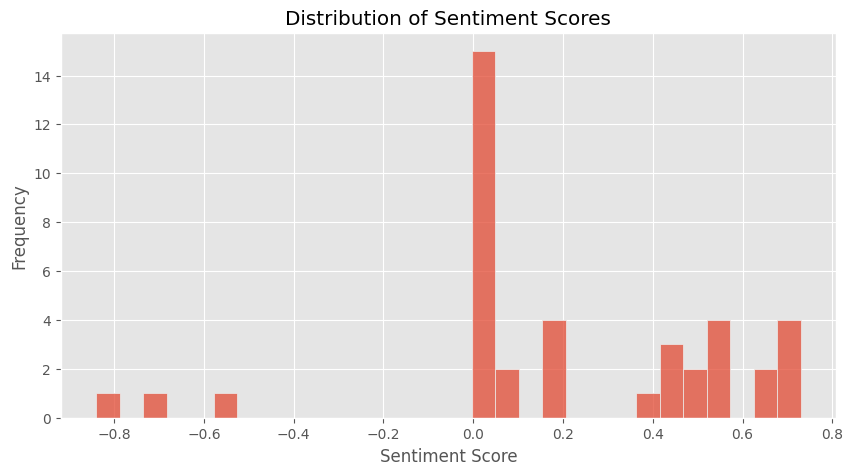

In [61]:
plt.figure(figsize=(10,5))

sns.histplot(news_df['sentiment_score'], bins=30)

plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')

plt.show()

## Calculate Daily Stock Returns

In [62]:
# Compute daily percentage returns
stock_df['daily_return'] = stock_df['Close'].pct_change() * 100

# Remove missing values
stock_df.dropna(inplace=True)

stock_df[['Date', 'Close', 'daily_return']].head()

,Date,Close,daily_return
1,2009-01-05,2.836553,4.220416
2,2009-01-06,2.789767,-1.649399
3,2009-01-07,2.729484,-2.160860
4,2009-01-08,2.780169,1.856959
5,2009-01-09,2.716589,-2.286921


## Aggregate Daily Sentiment and Merge Datasets

In [63]:
# Aggregate average daily sentiment
daily_sentiment = news_df.groupby(
    ['aligned_date', 'stock']
).agg({
    'sentiment_score': 'mean',
    'sentiment_label': lambda x: x.mode()[0]
}).reset_index()

# Merge with stock returns
merged_df = pd.merge(
    daily_sentiment,
    stock_df,
    left_on=['aligned_date', 'stock'],
    right_on=['date_only', 'stock'],
    how='inner'
)

print("Merged Dataset Shape:", merged_df.shape)

merged_df.head()

Merged Dataset Shape: (14, 12)


,aligned_date,stock,sentiment_score,sentiment_label,Date,Close,High,Low,Open,Volume,date_only,daily_return
0,2020-06-01,NVDA,0.421500,Positive,2020-06-01,8.772822,8.807192,8.656516,8.799720,389876000,2020-06-01,-0.780224
1,2020-06-02,NVDA,0.220200,Neutral,2020-06-02,8.791748,8.803703,8.625133,8.762859,391320000,2020-06-02,0.215731
2,2020-06-04,GOOG,0.000000,Neutral,2020-06-04,70.129089,71.458985,69.759124,71.033893,29686000,2020-06-04,-1.684800
3,2020-06-05,GOOG,-0.411033,Negative,2020-06-05,71.430679,71.761416,69.822188,70.178249,34698000,2020-06-05,1.855992
4,2020-06-08,GOOG,0.542300,Positive,2020-06-08,71.838890,71.907421,70.633637,70.633637,28084000,2020-06-08,0.571478


## Compute Pearson Correlation

In [64]:
correlation, p_value = pearsonr(
    merged_df['sentiment_score'],
    merged_df['daily_return']
)

print("Pearson Correlation:", correlation)

print("P-value:", p_value)

Pearson Correlation: 0.08676109552971699
P-value: 0.7680551017555681


## Visualize Correlation Between Sentiment and Stock Returns

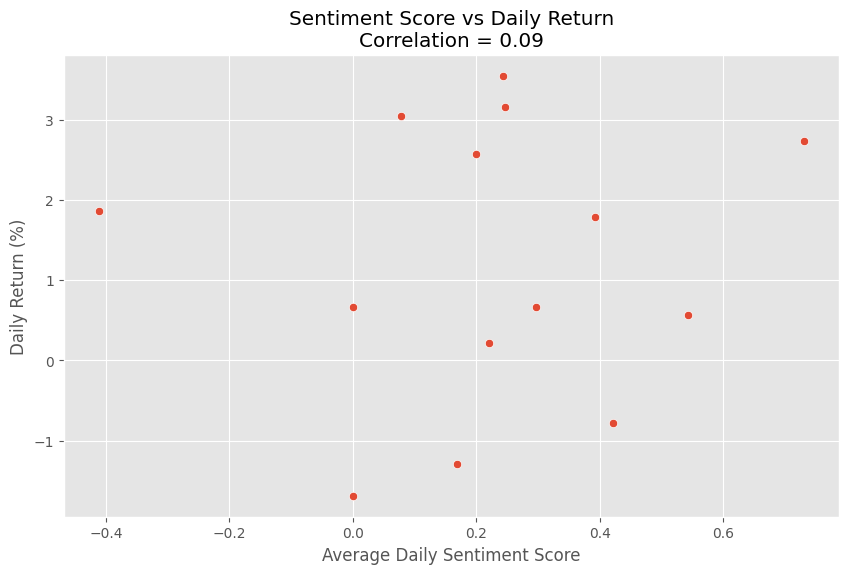

In [65]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=merged_df,
    x='sentiment_score',
    y='daily_return'
)

plt.title(f'Sentiment Score vs Daily Return\nCorrelation = {correlation:.2f}')

plt.xlabel('Average Daily Sentiment Score')

plt.ylabel('Daily Return (%)')

plt.show()

## Average Return by Sentiment Category

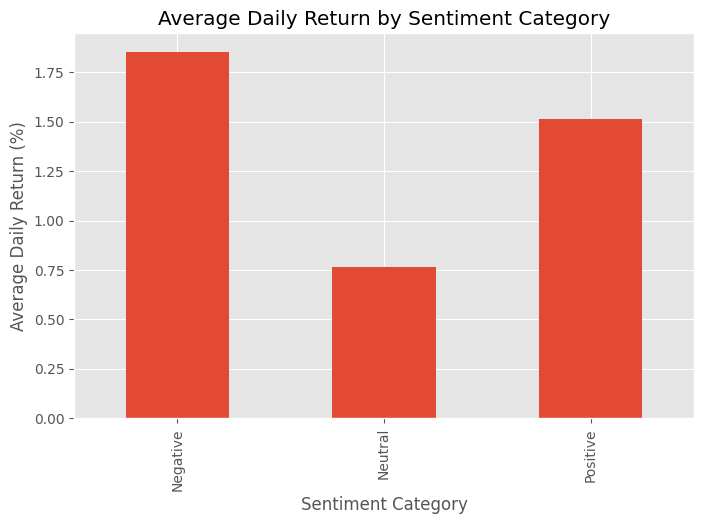

sentiment_label
Negative    1.855992
Neutral     0.767578
Positive    1.514366
Name: daily_return, dtype: float64


In [66]:
category_returns = merged_df.groupby(
    'sentiment_label'
)['daily_return'].mean()

plt.figure(figsize=(8,5))

category_returns.plot(kind='bar')

plt.title('Average Daily Return by Sentiment Category')

plt.xlabel('Sentiment Category')

plt.ylabel('Average Daily Return (%)')

plt.show()

print(category_returns)

## Correlation Heatmap

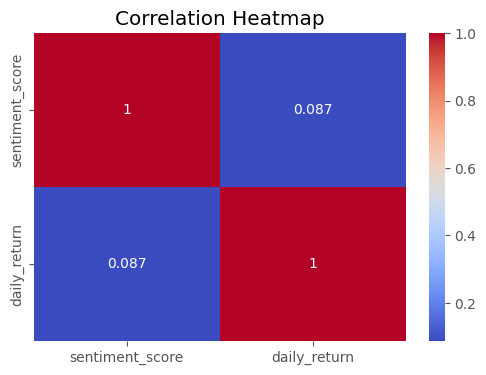

In [67]:
plt.figure(figsize=(6,4))

sns.heatmap(
    merged_df[['sentiment_score', 'daily_return']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

## Daily News Volume Over Time

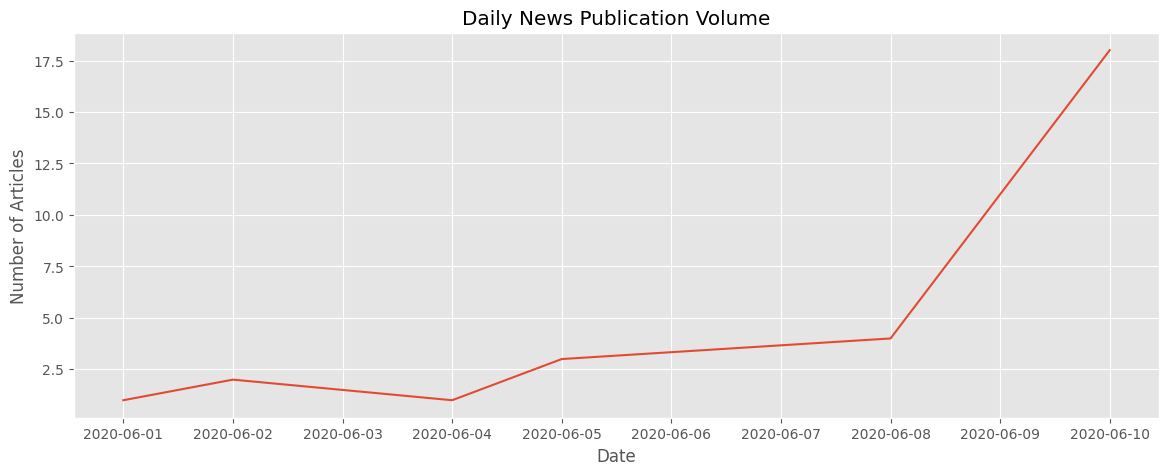

In [68]:
daily_news_volume = news_df.groupby('aligned_date').size()

plt.figure(figsize=(14,5))

daily_news_volume.plot()

plt.title('Daily News Publication Volume')

plt.xlabel('Date')

plt.ylabel('Number of Articles')

plt.show()